In [8]:
# Import required libraries
import pandas as pd

In [10]:
# Load dataset
df = pd.read_csv("mental_health.csv")

In [12]:
# View first 5 rows to understand structure
df.head()

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [14]:
# Check dataset shape (rows, columns)
df.shape

(1259, 27)

In [16]:
# Check column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Timestamp                  1259 non-null   object
 1   Age                        1259 non-null   int64 
 2   Gender                     1259 non-null   object
 3   Country                    1259 non-null   object
 4   state                      744 non-null    object
 5   self_employed              1241 non-null   object
 6   family_history             1259 non-null   object
 7   treatment                  1259 non-null   object
 8   work_interfere             995 non-null    object
 9   no_employees               1259 non-null   object
 10  remote_work                1259 non-null   object
 11  tech_company               1259 non-null   object
 12  benefits                   1259 non-null   object
 13  care_options               1259 non-null   object
 14  wellness

In [15]:
# Check missing values per column
df.isnull().sum()

Timestamp                       0
Age                             0
Gender                          0
Country                         0
state                         515
self_employed                  18
family_history                  0
treatment                       0
work_interfere                264
no_employees                    0
remote_work                     0
tech_company                    0
benefits                        0
care_options                    0
wellness_program                0
seek_help                       0
anonymity                       0
leave                           0
mental_health_consequence       0
phys_health_consequence         0
coworkers                       0
supervisor                      0
mental_health_interview         0
phys_health_interview           0
mental_vs_physical              0
obs_consequence                 0
comments                     1095
dtype: int64

In [18]:
# Drop irrelevant columns (not useful for analysis)
df.drop("state", axis=1, inplace=True)

In [20]:
# Handle missing values in important categorical features
df["work_interfere"] = df["work_interfere"].fillna("Unknown")
df["work_interfere"].value_counts(dropna=False)

work_interfere
Sometimes    465
Unknown      264
Never        213
Rarely       173
Often        144
Name: count, dtype: int64

In [22]:
# Handle missing values in important categorical features
df["self_employed"] = df["self_employed"].fillna("Unknown")

In [24]:
df["self_employed"].value_counts(dropna=False)

self_employed
No         1095
Yes         146
Unknown      18
Name: count, dtype: int64

In [39]:
# Remove unrealistic age values (data cleaning based on domain knowledge)
df = df[(df["Age"] >= 18) & (df["Age"] <= 65)]

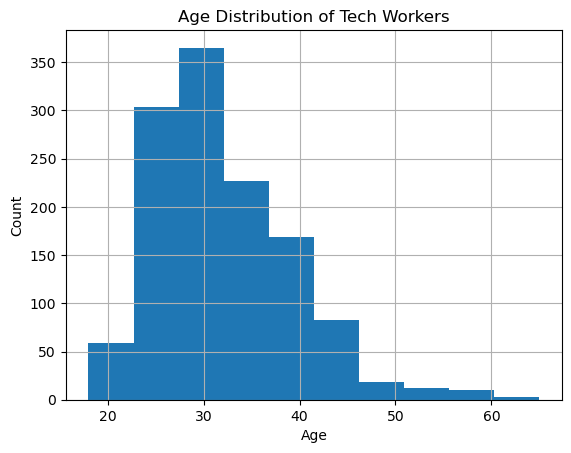

In [41]:
import matplotlib.pyplot as plt

df["Age"].hist(bins=10)
plt.title("Age Distribution of Tech Workers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


In [47]:
df["Gender"] = df["Gender"].str.lower()

In [49]:
# Standardize inconsistent gender values
def clean_gender(x):
    if "male" in x or "m" == x or "man" in x or "guy" in x:
        return "male"
    elif "female" in x or "f" == x or "woman" in x:
        return "female"
    else:
        return "other"


In [51]:
df["Gender"] = df["Gender"].apply(clean_gender)

In [53]:
df["Gender"].value_counts()

Gender
male      1176
female      53
other       21
Name: count, dtype: int64

<Axes: xlabel='Gender'>

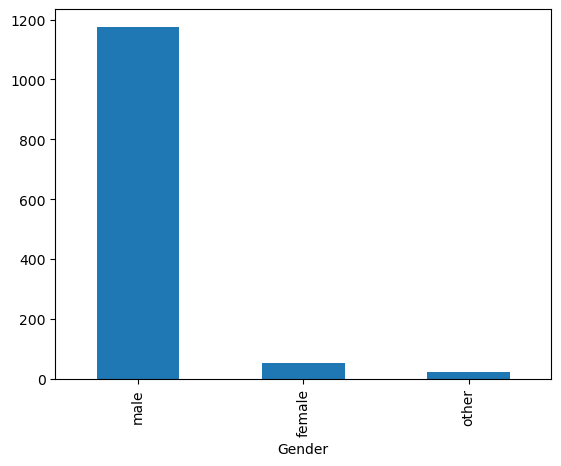

In [55]:
df["Gender"].value_counts().plot(kind="bar")

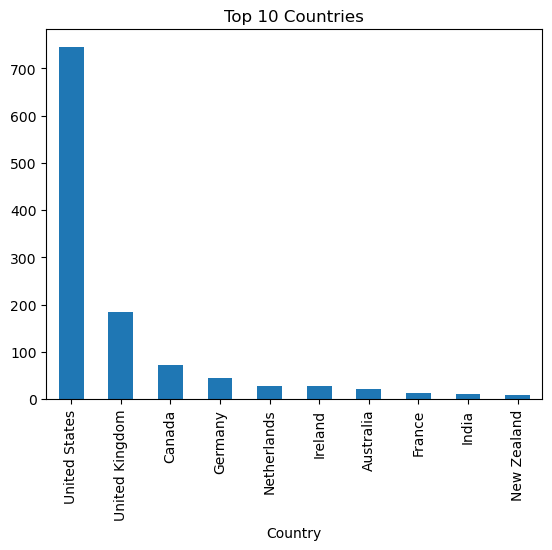

In [57]:
df["Country"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Countries")
plt.show()

In [59]:
pd.crosstab(df["family_history"], df["treatment"])

treatment,No,Yes
family_history,,
No,492,270
Yes,127,361


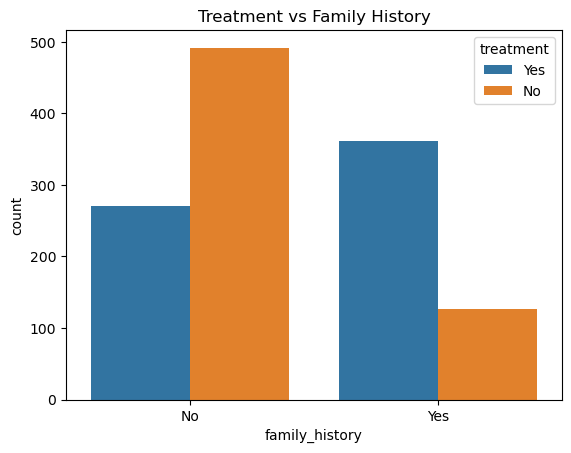

In [61]:
# Compare treatment vs family history
import seaborn as sns

sns.countplot(data=df, x="family_history", hue="treatment")
plt.title("Treatment vs Family History")
plt.show()

In [ ]:
#Individuals with a family history of mental health issues are significantly more likely to seek treatment, suggesting that awareness, familiarity, or genetic predisposition may play a key role in help-seeking behavior.

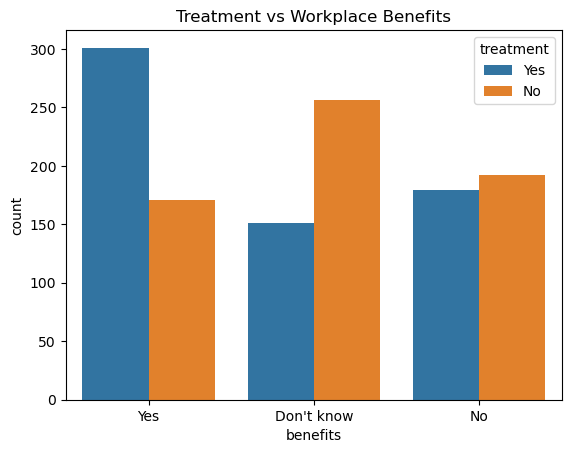

In [63]:
sns.countplot(data=df, x="benefits", hue="treatment")
plt.title("Treatment vs Workplace Benefits")
plt.show()

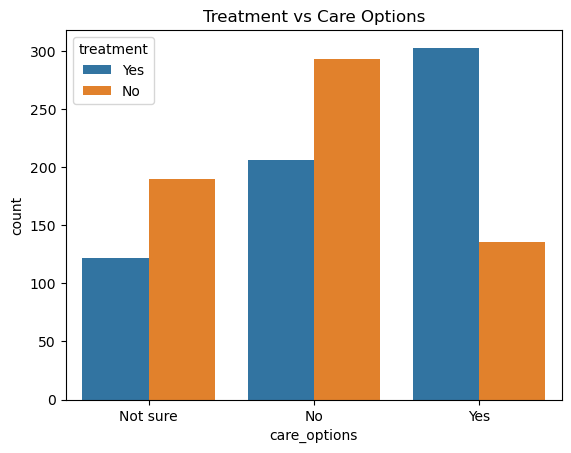

In [65]:
sns.countplot(data=df, x="care_options", hue="treatment")
plt.title("Treatment vs Care Options")
plt.show()

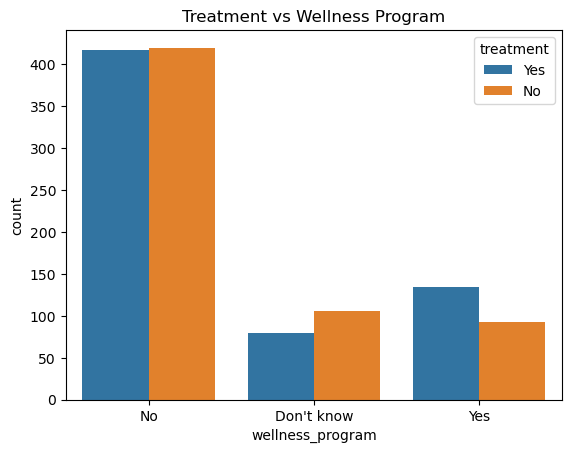

In [67]:
sns.countplot(data=df, x="wellness_program", hue="treatment")
plt.title("Treatment vs Wellness Program")
plt.show()

In [71]:
df["work_interfere"].value_counts()

work_interfere
Sometimes    464
Unknown      262
Never        211
Rarely       173
Often        140
Name: count, dtype: int64

In [79]:
# Analyze how work interference affects treatment
pd.crosstab(df["work_interfere"], df["treatment"], normalize="index")

treatment,No,Yes
work_interfere,,
Never,0.862559,0.137441
Often,0.150000,0.850000
Rarely,0.294798,0.705202
Sometimes,0.230603,0.769397
Unknown,0.984733,0.015267


<Axes: xlabel='work_interfere'>

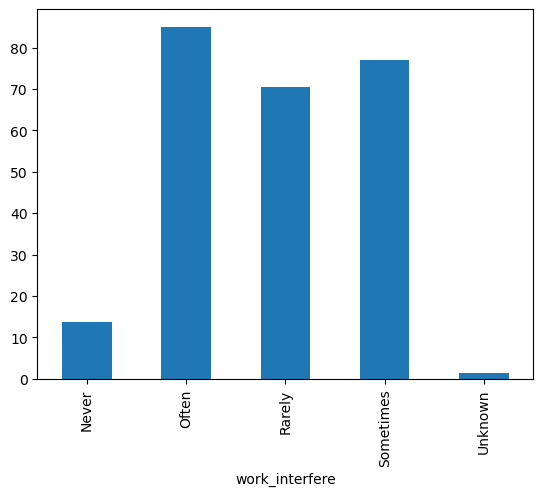

In [83]:
(pd.crosstab(df["work_interfere"], df["treatment"], normalize="index")["Yes"] * 100).plot(kind="bar")


In [ ]:
## Machine Learning Model
We build a Logistic Regression model to predict whether a tech worker will seek mental health treatment based on workplace and personal factors.


In [85]:
# Convert target variable to numeric
df["treatment"] = df["treatment"].map({"Yes": 1, "No": 0})

In [87]:
# Define features and target
X = df.drop("treatment", axis=1)
y = df["treatment"]

In [89]:
# Convert categorical variables to numeric
X = pd.get_dummies(X, drop_first=True)

In [91]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [93]:
# Train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [95]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.84
              precision    recall  f1-score   support

           0       0.84      0.80      0.82       115
           1       0.84      0.87      0.86       135

    accuracy                           0.84       250
   macro avg       0.84      0.84      0.84       250
weighted avg       0.84      0.84      0.84       250

